# 5-Fold Cross-Validation Results Analysis

This notebook analyzes the 5-fold cross-validation results for all subjects (sub-01 to sub-10) using the Specific model.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.8

sns.set_palette("colorblind")

In [35]:
def load_fold_metrics(subject, model, num_folds, fold):
    """Load metrics.csv for a specific fold"""
    path = Path(f"../logs/train/runs/{model}/{model}_k{num_folds}_fold{fold}_{subject}/csv/version_0/metrics.csv")
    if path.exists():
        return pd.read_csv(path)
    return None

In [36]:
model = "flatnet"
num_folds = 5
subjects = [f"sub-{i:02d}" for i in range(1, 11)]

results = {}
for subject in subjects:
    fold_data = []
    for fold in range(num_folds):
        df = load_fold_metrics(subject, model, num_folds, fold)
        if df is not None:
            fold_data.append(df)
    if fold_data:
        results[subject] = fold_data
        
print(f"Loaded data for {len(results)} subjects")

Loaded data for 10 subjects


In [37]:
def extract_best_metrics(fold_data):
    """Extract best test metrics from each fold"""
    metrics = []
    for df in fold_data:
        test_row = df[df['test/loss'].notna()].iloc[-1] if not df[df['test/loss'].notna()].empty else None
        if test_row is not None:
            metrics.append({
                'test_loss': test_row['test/loss'],
                'test_top1_acc_200': test_row['test/top1_acc_retrieval_200'],
                'test_top5_acc_200': test_row['test/top5_acc_retrieval_200']
            })
    return pd.DataFrame(metrics)

## Results Summary

Calculate average test metrics across 5 folds for each subject.

In [38]:
summary = []
for subject, fold_data in results.items():
    metrics_df = extract_best_metrics(fold_data)
    if not metrics_df.empty:
        summary.append({
            'subject': subject,
            'test_loss_mean': metrics_df['test_loss'].mean(),
            'test_loss_std': metrics_df['test_loss'].std(),
            'test_top1_acc_mean': metrics_df['test_top1_acc_200'].mean(),
            'test_top1_acc_std': metrics_df['test_top1_acc_200'].std(),
            'test_top5_acc_mean': metrics_df['test_top5_acc_200'].mean(),
            'test_top5_acc_std': metrics_df['test_top5_acc_200'].std()
        })

summary_df = pd.DataFrame(summary)
summary_df

,subject,test_loss_mean,test_loss_std,test_top1_acc_mean,test_top1_acc_std,test_top5_acc_mean,test_top5_acc_std
0,sub-01,2.888535,0.188270,0.294,0.036469,0.599,0.017464
1,sub-02,3.080657,0.242843,0.258,0.034749,0.559,0.060869
2,sub-03,2.823670,0.271281,0.305,0.027157,0.602,0.037014
3,sub-04,2.612160,0.072991,0.346,0.014748,0.645,0.020310
4,sub-05,3.428492,0.201571,0.201,0.018507,0.471,0.029875
5,sub-06,2.566416,0.050980,0.330,0.014577,0.652,0.009747
6,sub-07,2.869062,0.217265,0.304,0.026315,0.599,0.021622
7,sub-08,2.500047,0.172751,0.348,0.027749,0.673,0.044102
8,sub-09,2.987848,0.157925,0.314,0.048010,0.632,0.034928
9,sub-10,2.304635,0.016164,0.374,0.016355,0.711,0.007416


## Comparison: FlatNet vs FlatNet+KG

Compare regular FlatNet with FlatNet enhanced by knowledge graph for each subject.

In [39]:
def load_kg_fold_metrics(subject, model, num_folds, fold):
    """Load metrics.csv for KG version"""
    path = Path(f"../logs/train/runs/{model}/{model}_kg_k{num_folds}_fold{fold}_{subject}/csv/version_0/metrics.csv")
    if path.exists():
        return pd.read_csv(path)
    return None

kg_results = {}
for subject in subjects:
    fold_data = []
    for fold in range(num_folds):
        df = load_kg_fold_metrics(subject, model, num_folds, fold)
        if df is not None:
            fold_data.append(df)
    if fold_data:
        kg_results[subject] = fold_data
        
print(f"Loaded KG data for {len(kg_results)} subjects")

Loaded KG data for 10 subjects


In [40]:
kg_summary = []
for subject, fold_data in kg_results.items():
    metrics_df = extract_best_metrics(fold_data)
    if not metrics_df.empty:
        kg_summary.append({
            'subject': subject,
            'test_loss_mean': metrics_df['test_loss'].mean(),
            'test_loss_std': metrics_df['test_loss'].std(),
            'test_top1_acc_mean': metrics_df['test_top1_acc_200'].mean(),
            'test_top1_acc_std': metrics_df['test_top1_acc_200'].std(),
            'test_top5_acc_mean': metrics_df['test_top5_acc_200'].mean(),
            'test_top5_acc_std': metrics_df['test_top5_acc_200'].std()
        })

kg_summary_df = pd.DataFrame(kg_summary)
kg_summary_df

,subject,test_loss_mean,test_loss_std,test_top1_acc_mean,test_top1_acc_std,test_top5_acc_mean,test_top5_acc_std
0,sub-01,2.716613,0.025500,0.322,0.023345,0.620,0.013229
1,sub-02,2.819211,0.024449,0.286,0.013874,0.588,0.029069
2,sub-03,2.768845,0.195630,0.288,0.032901,0.594,0.031504
3,sub-04,2.479221,0.035044,0.350,0.016583,0.673,0.025884
4,sub-05,3.168539,0.194106,0.220,0.018028,0.491,0.026077
5,sub-06,2.562708,0.083915,0.320,0.012748,0.670,0.017678
6,sub-07,2.695634,0.157544,0.301,0.031504,0.614,0.023292
7,sub-08,2.285509,0.010003,0.358,0.016432,0.719,0.017464
8,sub-09,2.758450,0.175457,0.317,0.042071,0.645,0.020916
9,sub-10,2.414425,0.091617,0.332,0.031345,0.687,0.020797


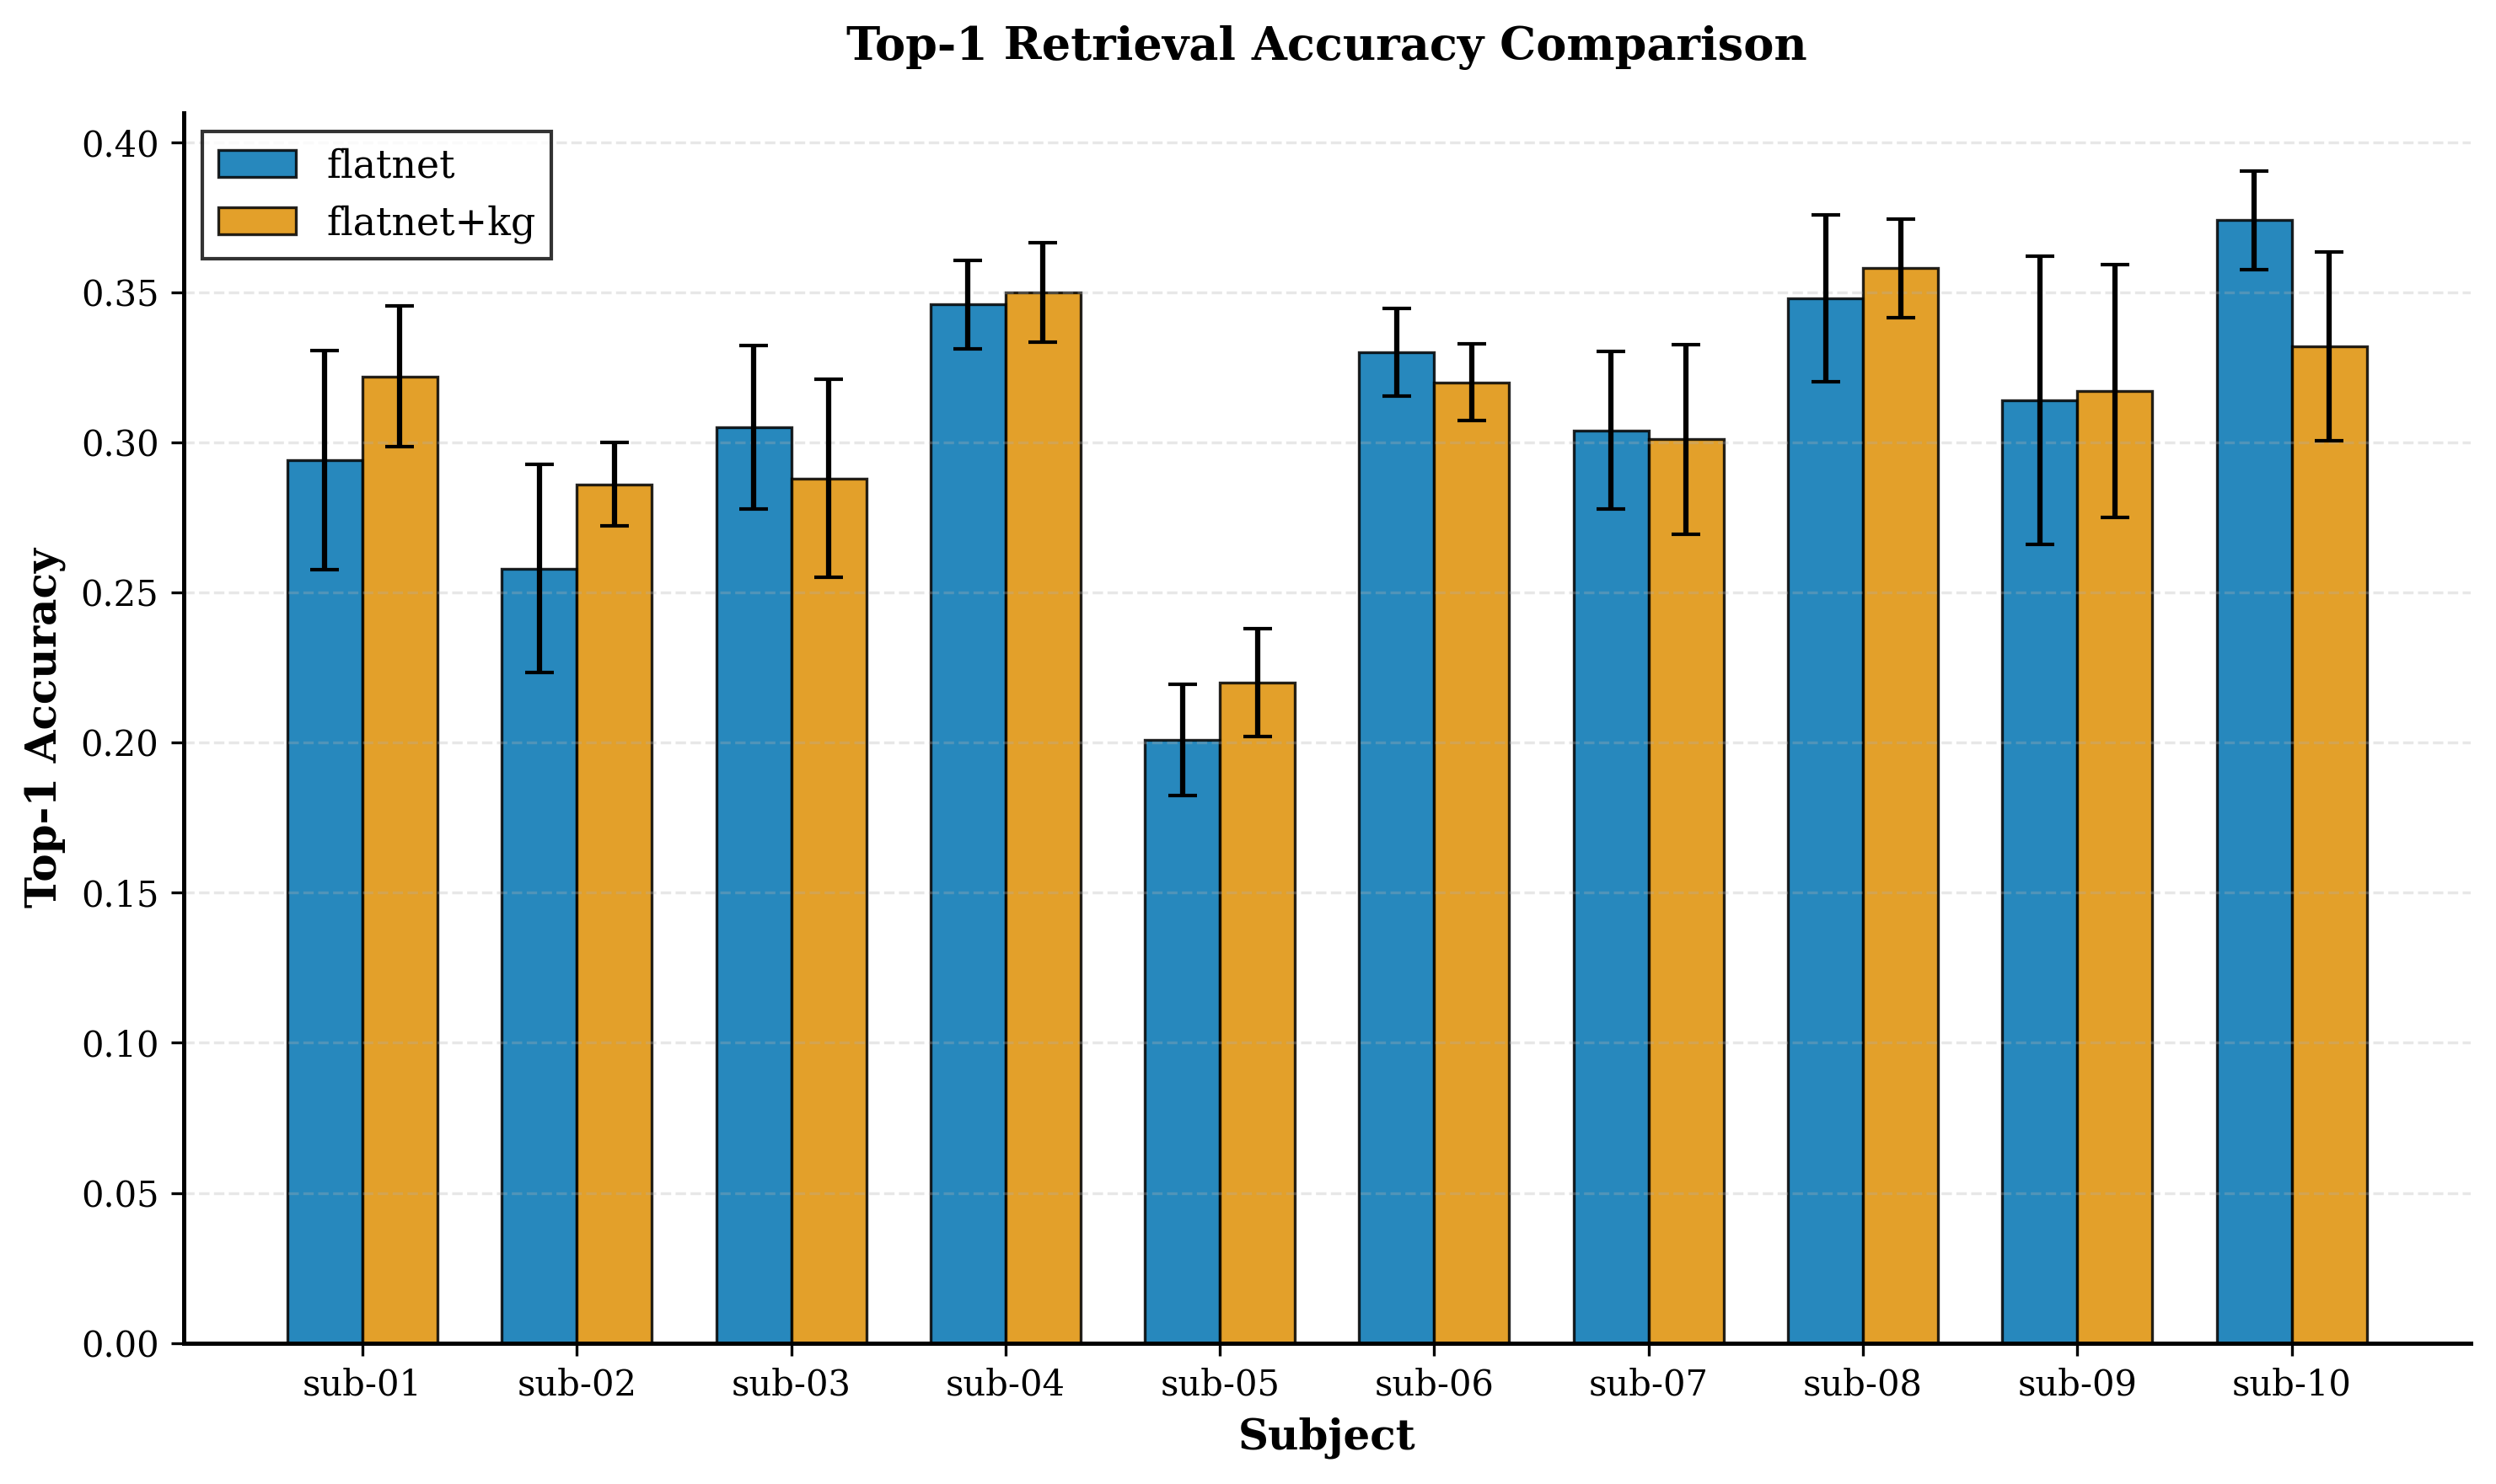

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, summary_df['test_top1_acc_mean'], width, yerr=summary_df['test_top1_acc_std'], 
       capsize=4, alpha=0.85, label=f'{model}', color=colors[0], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_summary_df['test_top1_acc_mean'], width, yerr=kg_summary_df['test_top1_acc_std'], 
       capsize=4, alpha=0.85, label=f'{model}+kg', color=colors[1], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Top-1 Accuracy', fontweight='bold')
ax.set_title('Top-1 Retrieval Accuracy Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

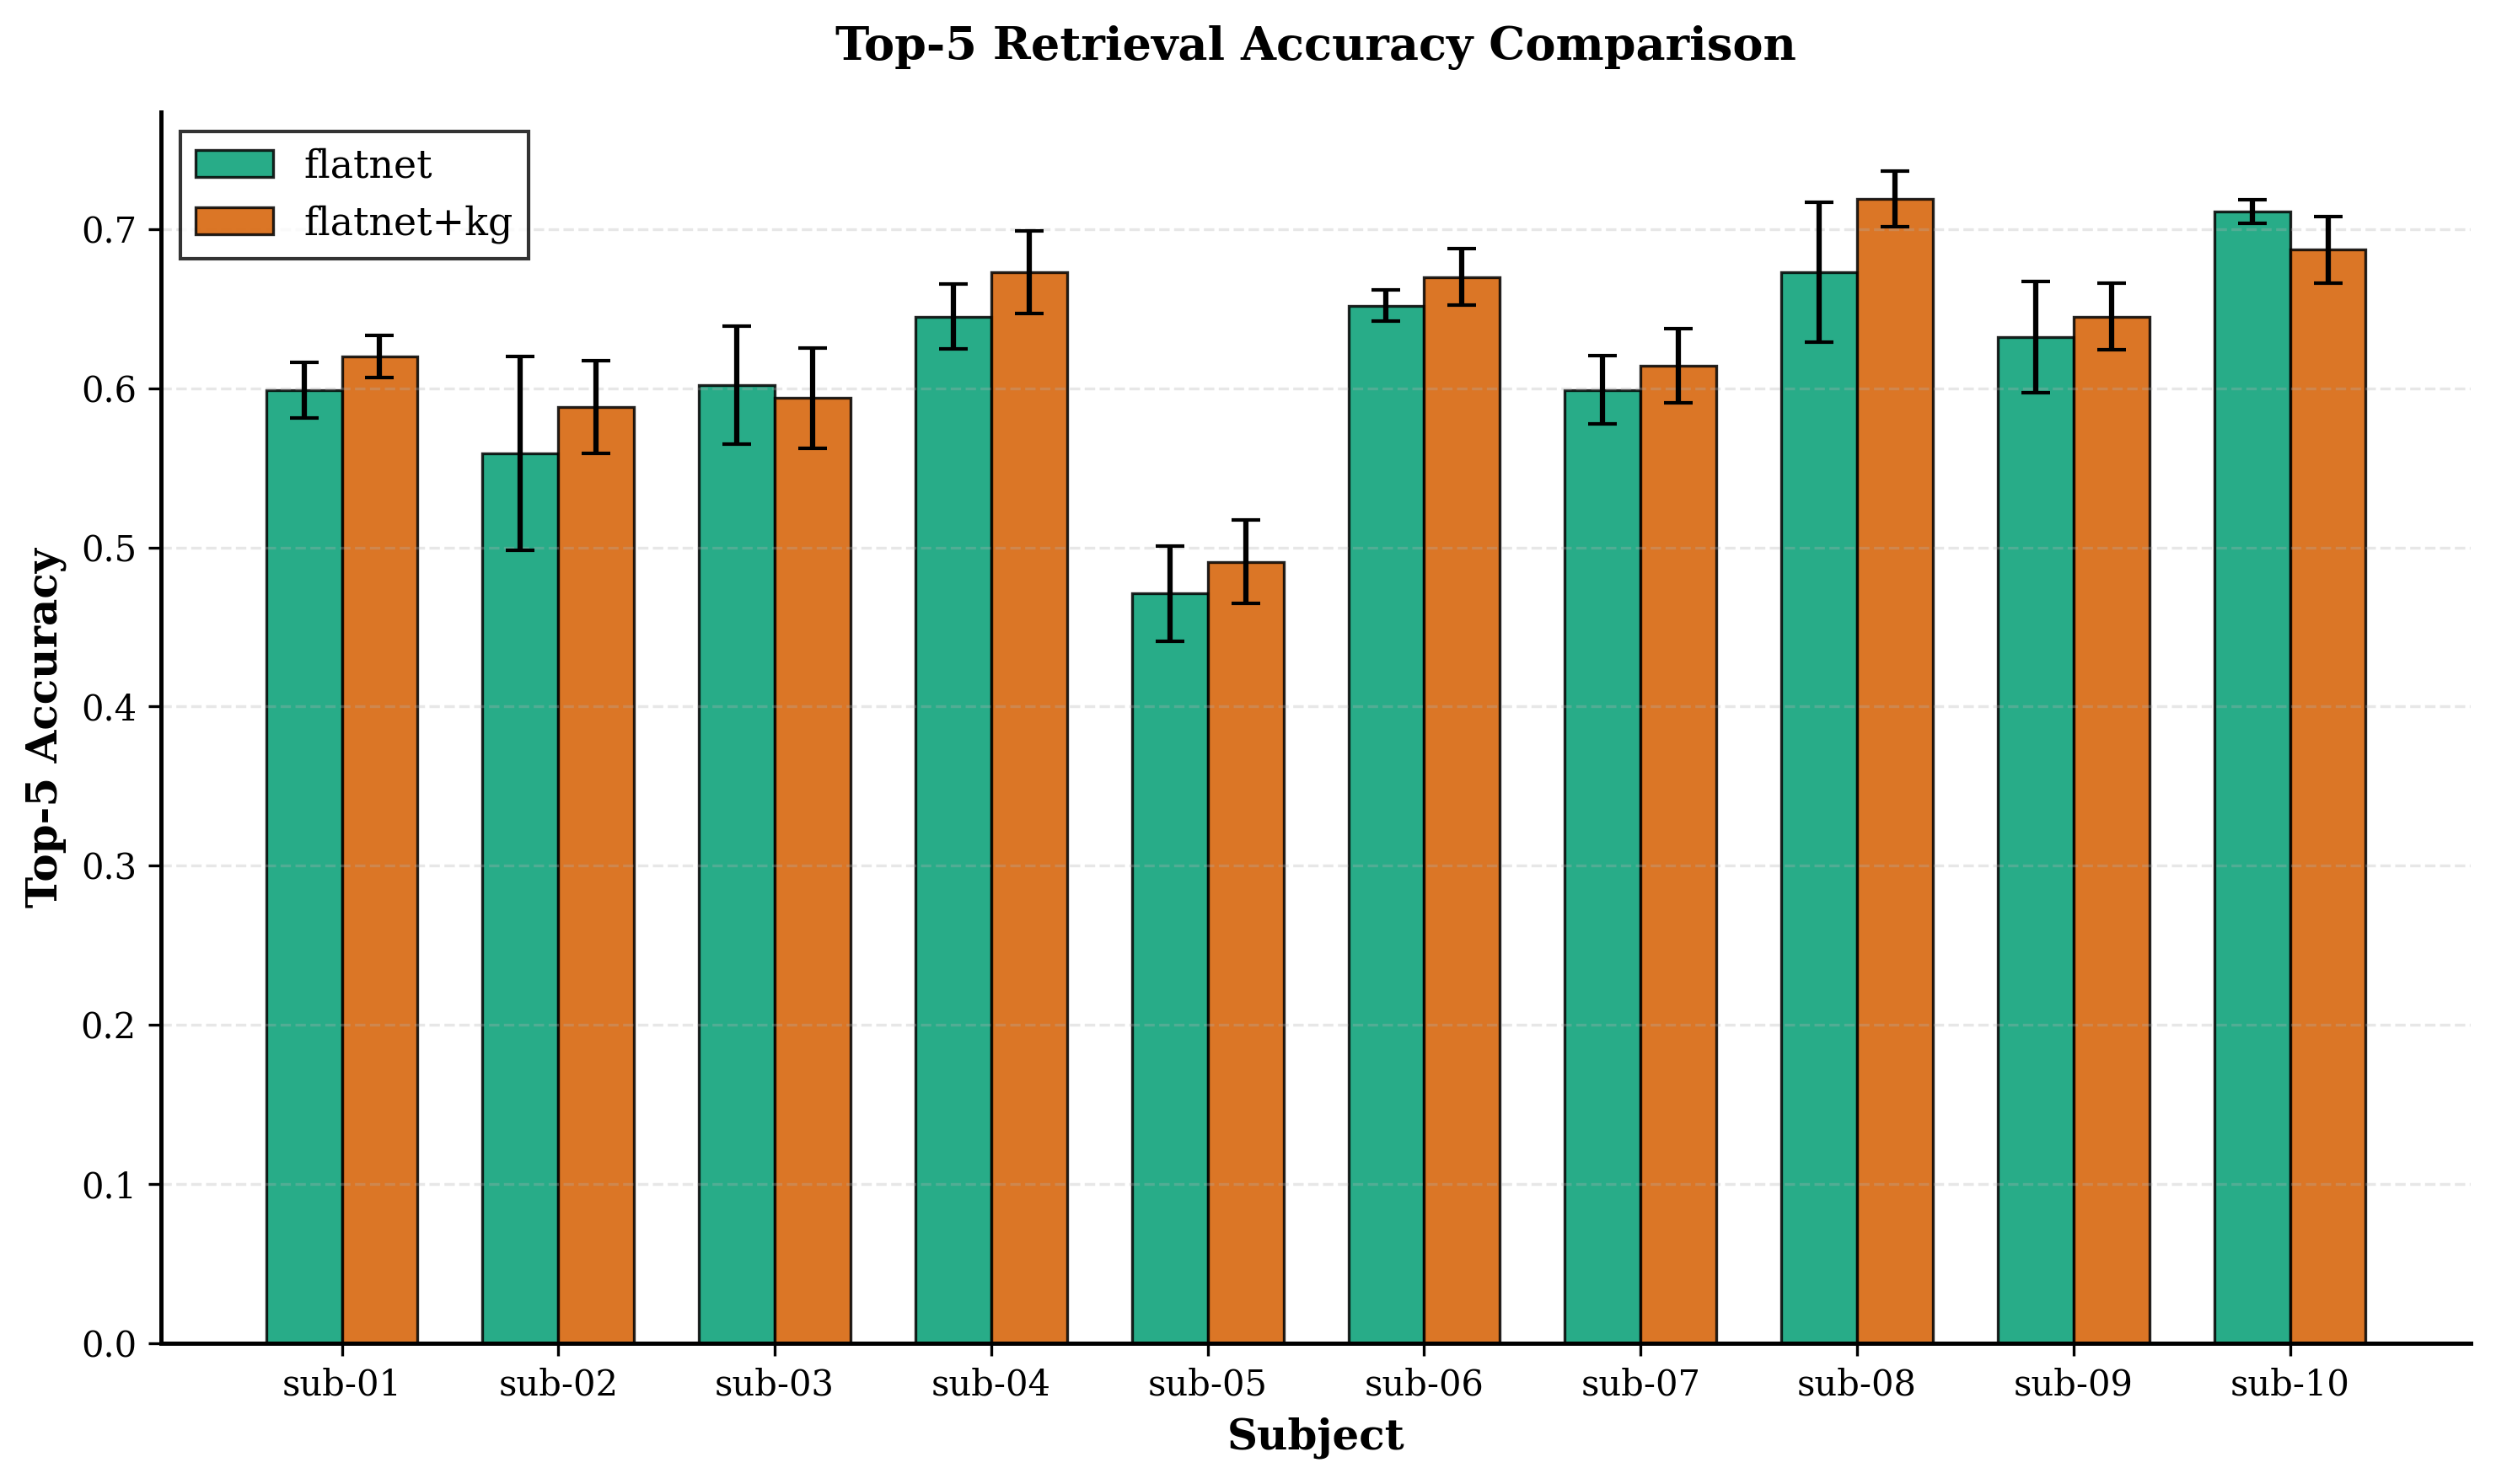

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, summary_df['test_top5_acc_mean'], width, yerr=summary_df['test_top5_acc_std'], 
       capsize=4, alpha=0.85, label=f'{model}', color=colors[2], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_summary_df['test_top5_acc_mean'], width, yerr=kg_summary_df['test_top5_acc_std'], 
       capsize=4, alpha=0.85, label=f'{model}+kg', color=colors[3], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Top-5 Accuracy', fontweight='bold')
ax.set_title('Top-5 Retrieval Accuracy Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

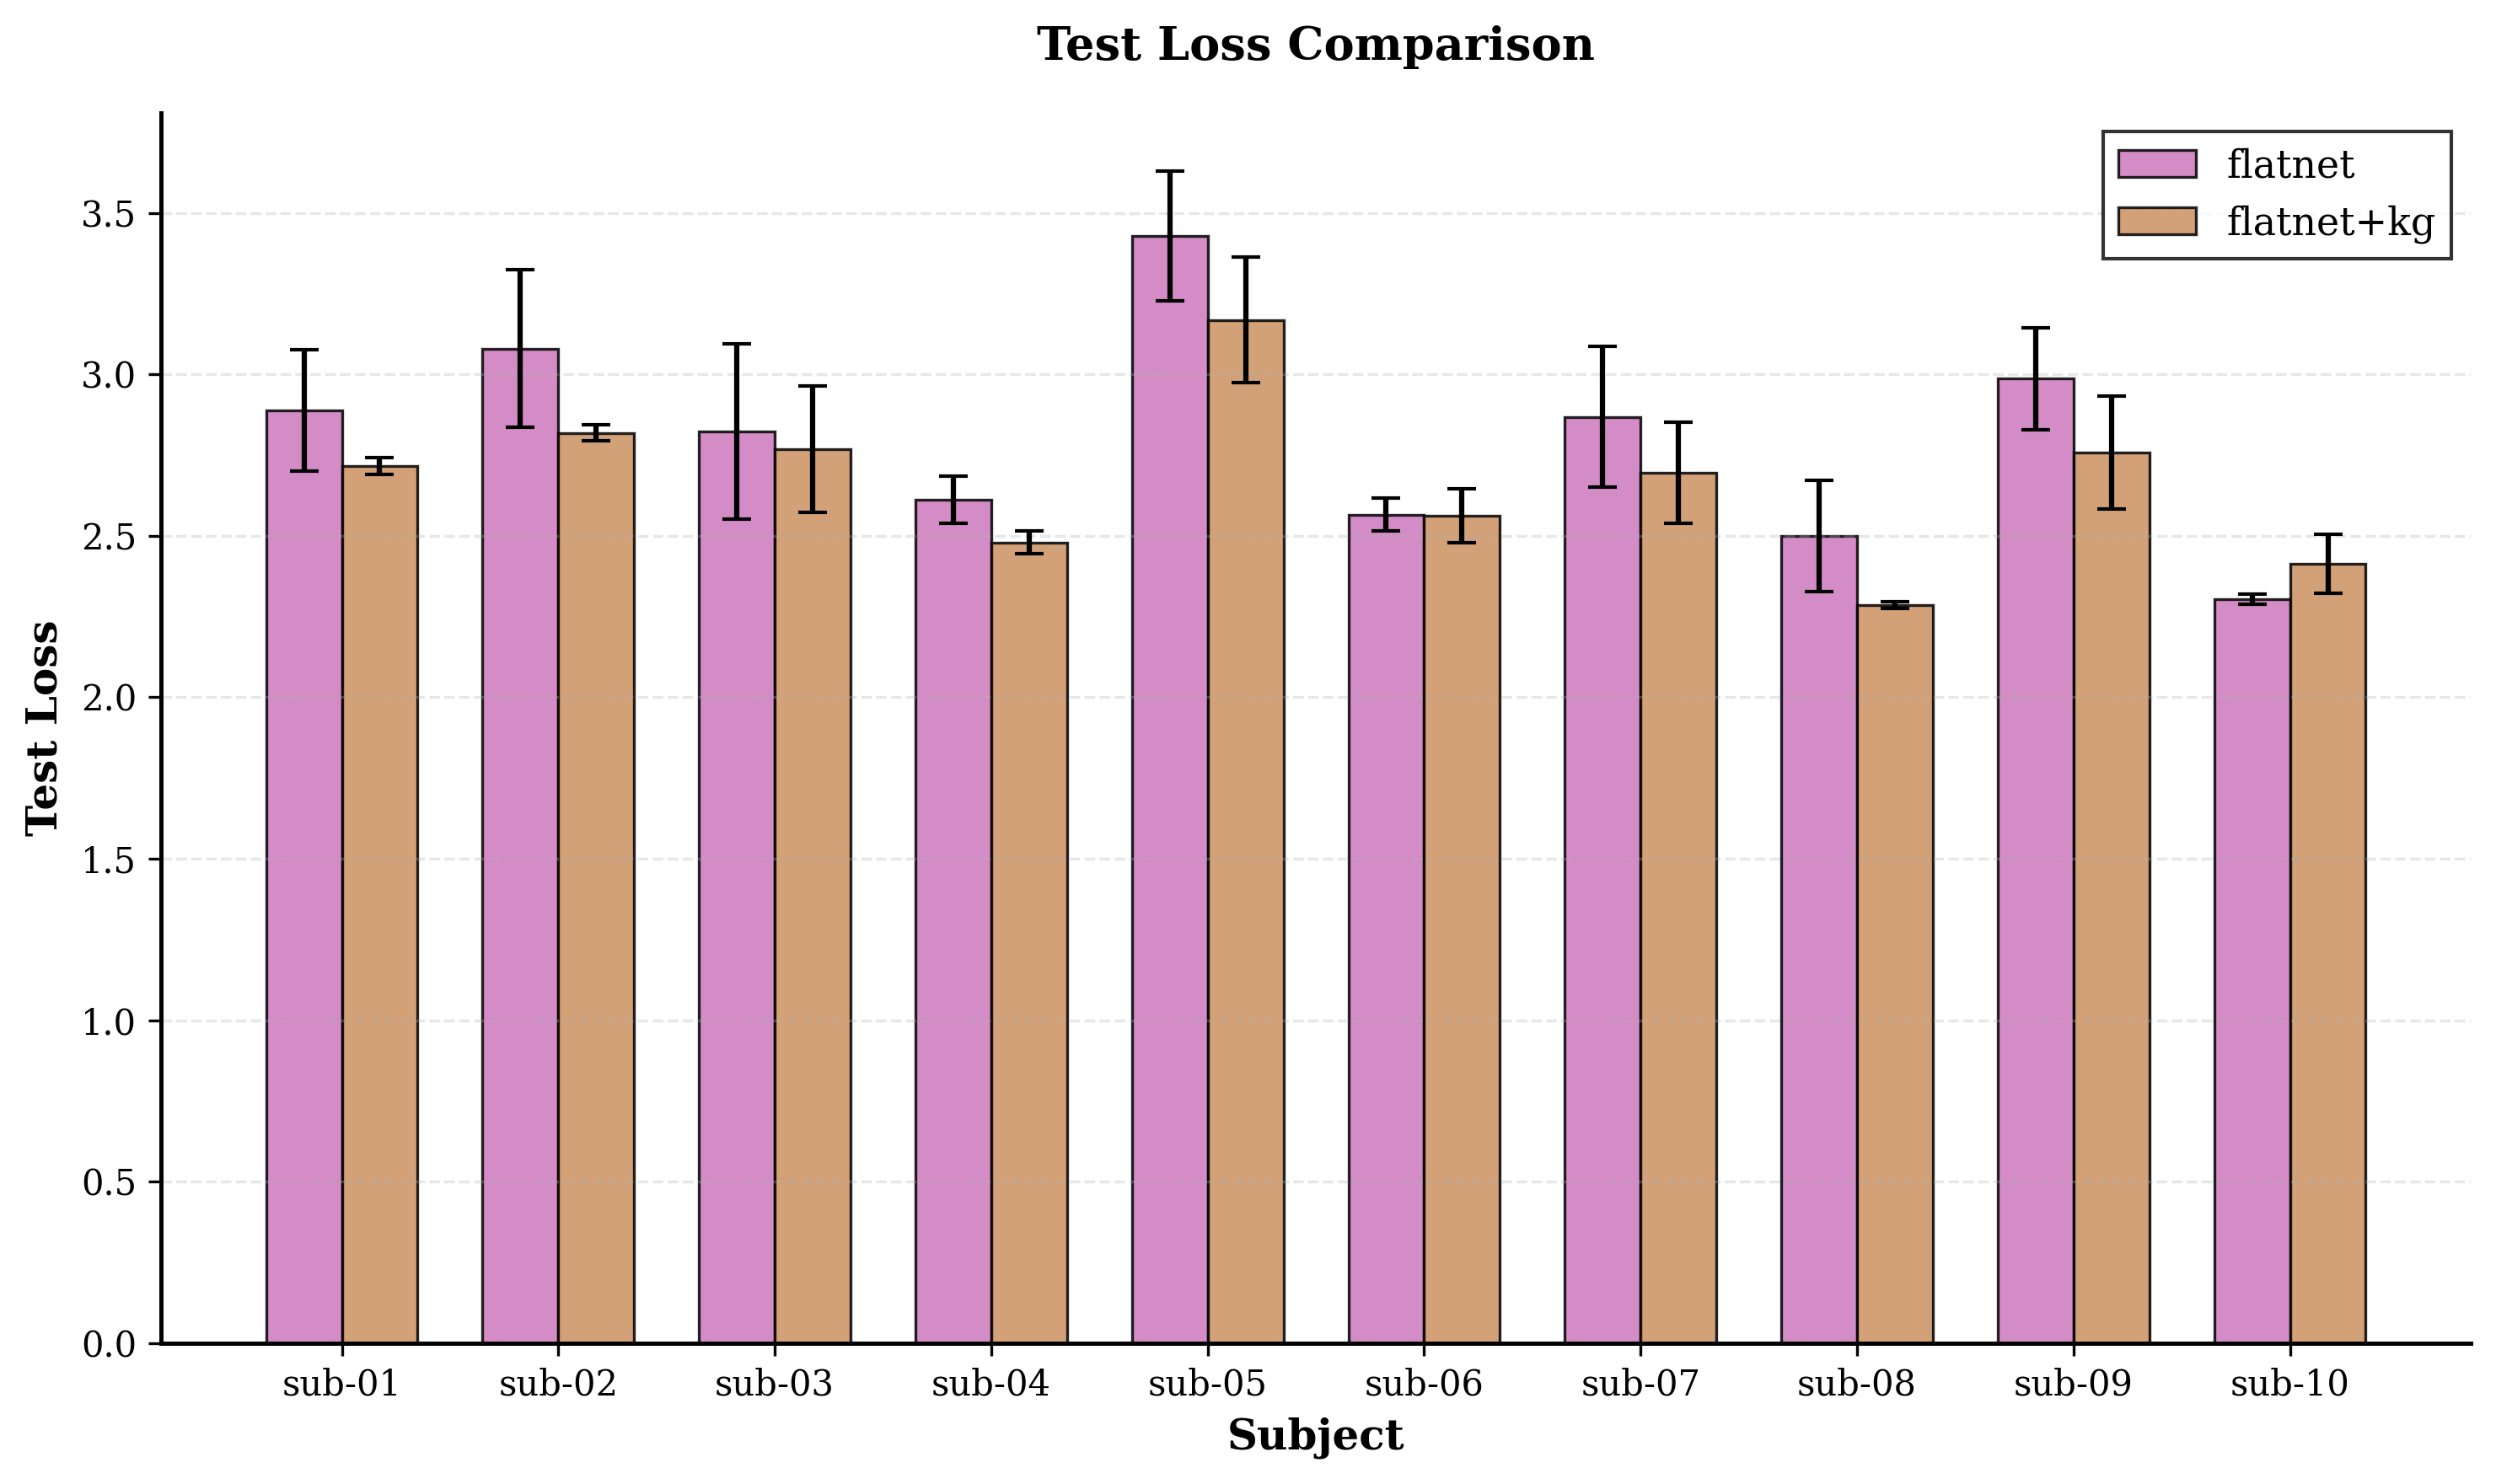

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, summary_df['test_loss_mean'], width, yerr=summary_df['test_loss_std'], 
       capsize=4, alpha=0.85, label=f'{model}', color=colors[4], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_summary_df['test_loss_mean'], width, yerr=kg_summary_df['test_loss_std'], 
       capsize=4, alpha=0.85, label=f'{model}+kg', color=colors[5], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Test Loss', fontweight='bold')
ax.set_title('Test Loss Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [44]:
improvement = pd.DataFrame({
    'subject': summary_df['subject'],
    'top1_improvement': ((kg_summary_df['test_top1_acc_mean'].values - summary_df['test_top1_acc_mean'].values) / summary_df['test_top1_acc_mean'].values * 100),
    'top5_improvement': ((kg_summary_df['test_top5_acc_mean'].values - summary_df['test_top5_acc_mean'].values) / summary_df['test_top5_acc_mean'].values * 100),
    'loss_improvement': ((summary_df['test_loss_mean'].values - kg_summary_df['test_loss_mean'].values) / summary_df['test_loss_mean'].values * 100)
})

print("Improvement with Knowledge Graph (%):")
print(f"Average Top-1 Accuracy: {improvement['top1_improvement'].mean():.2f}%")
print(f"Average Top-5 Accuracy: {improvement['top5_improvement'].mean():.2f}%")
print(f"Average Loss Reduction: {improvement['loss_improvement'].mean():.2f}%")
print("\nPer-subject improvement:")
improvement

Improvement with Knowledge Graph (%):
Average Top-1 Accuracy: 1.40%
Average Top-5 Accuracy: 2.67%
Average Loss Reduction: 4.67%

Per-subject improvement:


,subject,top1_improvement,top5_improvement,loss_improvement
0,sub-01,9.523809,3.505844,5.951880
1,sub-02,10.852717,5.187836,8.486700
2,sub-03,-5.573766,-1.328902,1.941609
3,sub-04,1.156068,4.341085,5.089208
4,sub-05,9.452737,4.246283,7.582143
5,sub-06,-3.030306,2.760737,0.144449
6,sub-07,-0.986843,2.504173,6.044749
7,sub-08,2.873564,6.835066,8.581341
8,sub-09,0.955415,2.056962,7.677688
9,sub-10,-11.229946,-3.375526,-4.763878
